# 👥 Customer Analysis: RFM Segmentation

This notebook implements the fourth dimension of our analytical framework: **Customer Analysis (RFM)**.

**Objective:** Segment customers based on their buying behavior to target marketing and CRM efforts.

| Metric | Meaning | Business Value |
| :--- | :--- | :--- |
| **Recency** | Days since last purchase | Identifying churn risk |
| **Frequency** | Total number of orders | Measuring loyalty |
| **Monetary** | Total spend amount | Identifying VIP customers |

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Filter for successful orders
success_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])].copy()

## 2. Calculating RFM Metrics

In [2]:
# Reference date for recency (day after the last order in the dataset)
ref_date = success_orders['OrderDate'].max() + dt.timedelta(days=1)

rfm = success_orders.groupby('CustomerID').agg({
    'OrderDate': lambda x: (ref_date - x.max()).days,
    'OrderID': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(f"RFM Summary:\n{rfm.describe()}")

RFM Summary:
            Recency     Frequency      Monetary
count  41738.000000  41738.000000  41738.000000
mean     654.583952      2.151996   1975.569172
std      486.892790      1.170634   1512.028791
min        1.000000      1.000000      6.190000
25%      240.000000      1.000000    790.105000
50%      549.000000      2.000000   1661.645000
75%     1001.000000      3.000000   2787.857500
max     1825.000000      9.000000  14876.570000


## 3. Visualizing Distributions

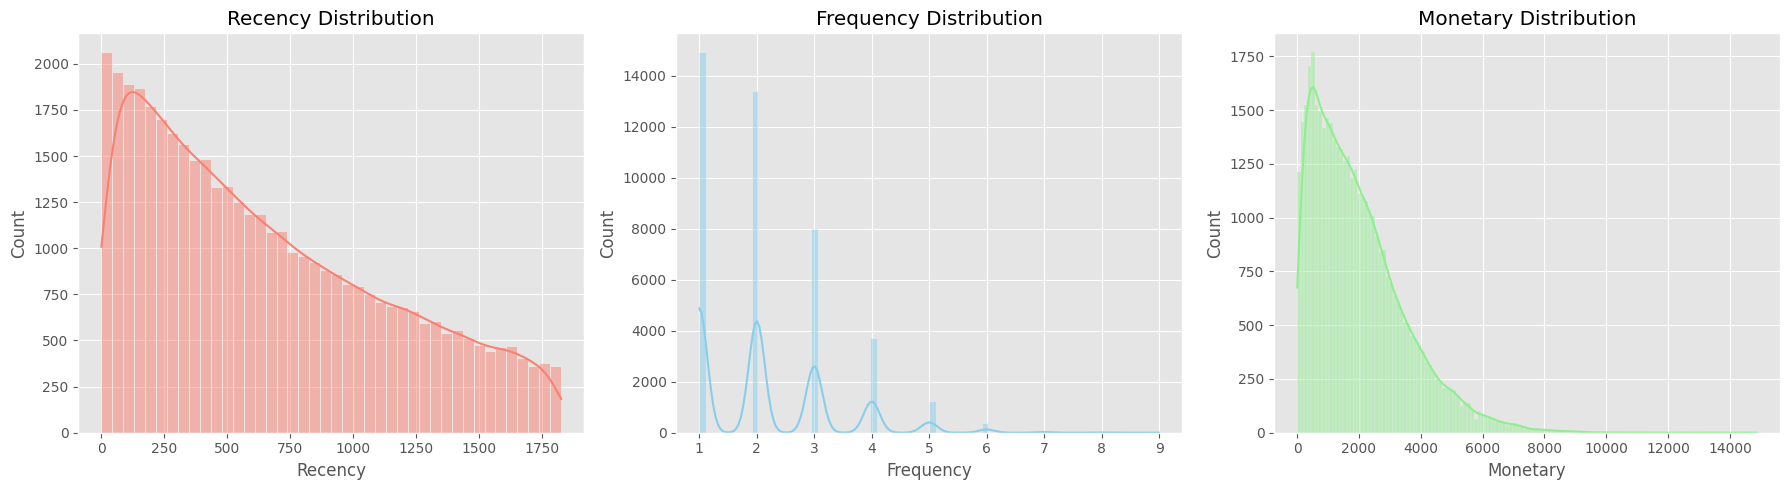

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='salmon').set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='skyblue').set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='lightgreen').set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

## 4. Simple Scoring & Segmentation
Creating simple tiers (1-5) based on quantiles.

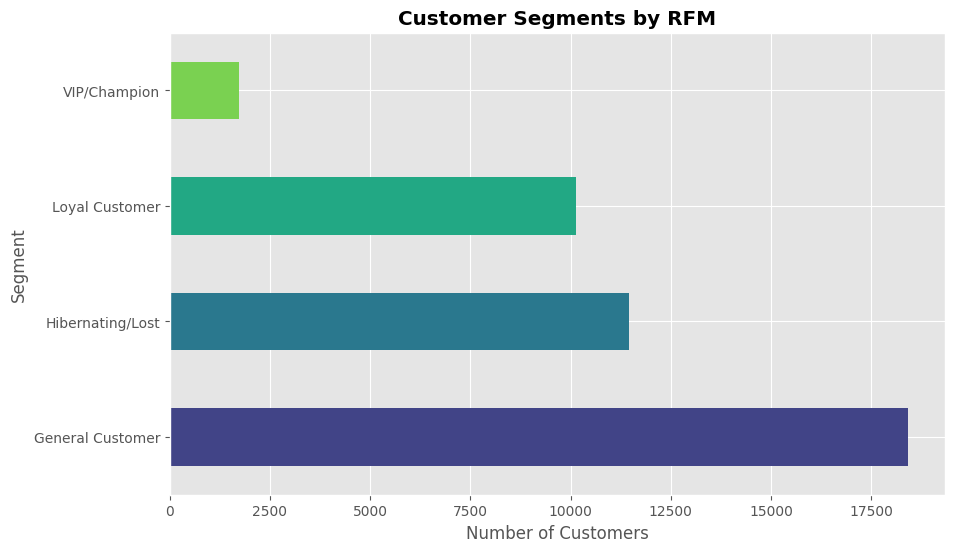

In [4]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Simple Segment Definition
def segment_customer(row):
    score = int(row['RFM_Score'])
    if score >= 555: return 'VIP/Champion'
    if score >= 444: return 'Loyal Customer'
    if score <= 222: return 'Hibernating/Lost'
    return 'General Customer'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='barh', color=sns.color_palette('viridis', len(segment_counts)))
plt.title('Customer Segments by RFM', fontweight='bold')
plt.xlabel('Number of Customers')
plt.show()